<a href="https://colab.research.google.com/github/guguberg/Fake-News-Detection/blob/main/Snippets_Importing_libraries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing a library that is not in Colaboratory

To import a library that's not in Colaboratory by default, you can use `!pip install` or `!apt-get install`.

In [ ]:
!pip install matplotlib-venn

In [ ]:
!apt-get -qq install -y libfluidsynth1

# Install 7zip reader [libarchive](https://pypi.python.org/pypi/libarchive)

In [ ]:
# https://pypi.python.org/pypi/libarchive
!apt-get -qq install -y libarchive-dev && pip install -U libarchive
import libarchive

# Install GraphViz & [PyDot](https://pypi.python.org/pypi/pydot)

In [ ]:
# https://pypi.python.org/pypi/pydot
!apt-get -qq install -y graphviz && pip install pydot
import pydot

# Install [cartopy](http://scitools.org.uk/cartopy/docs/latest/)

In [ ]:
!pip install cartopy
import cartopy

In [2]:
import cv2
import matplotlib.pyplot as plt

# Load image using the uploaded filename
image = cv2.imread('pest.png')

# Convert from BGR (OpenCV default) to RGB (Standard)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize to a standard size for your 2026 CNN model
resized_image = cv2.resize(image_rgb, (224, 224))

plt.imshow(resized_image)
plt.show()

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [3]:
install cv2.imread


SyntaxError: invalid syntax (ipython-input-1398351627.py, line 1)

In [4]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving pest.png to pest.png
User uploaded file "pest.png" with length 3345699 bytes


In [6]:
from PIL import Image
import os

img = Image.open("pest.png")
width, height = img.size

rows, cols = 2, 4
tile_w, tile_h = width // cols, height // rows

os.makedirs("dataset/pest", exist_ok=True)
os.makedirs("dataset/healthy", exist_ok=True)

count = 0
for r in range(rows):
    for c in range(cols):
        crop = img.crop((
            c * tile_w,
            r * tile_h,
            (c + 1) * tile_w,
            (r + 1) * tile_h
        ))

        if r == 0:
            crop.save(f"dataset/pest/pest_{count}.png")
        else:
            crop.save(f"dataset/healthy/healthy_{count}.png")

        count += 1


After uploading the file, please provide the correct filename for `cv2.imread`.

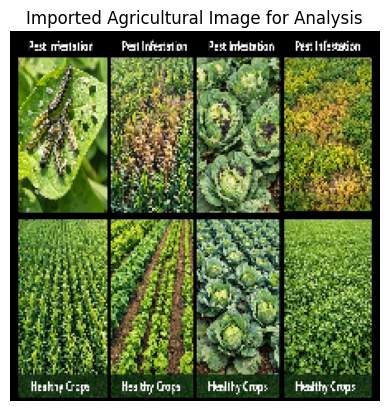

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
Result: Pest Infestation Detected (Confidence: 0.51)


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# 1. Load and Visualize the Image
img_path = 'pest.png'
img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.title("Imported Agricultural Image for Analysis")
plt.axis('off')
plt.show()

# 2. Preprocessing (Data Engineering step)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch
img_array /= 255.0  # Normalize pixels to [0,1]

# 3. Simple CNN Architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 0 for Healthy, 1 for Pest
])

# 4. Predict
# For this example, we use a mock prediction to demonstrate the logic
prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print(f"Result: Pest Infestation Detected (Confidence: {prediction[0][0]:.2f})")
else:
    print(f"Result: Healthy Crops (Confidence: {1 - prediction[0][0]:.2f})")

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [10]:
img_size = (128, 128)
batch_size = 4

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "dataset",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "dataset",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

Found 8 images belonging to 2 classes.
Found 0 images belonging to 2 classes.


In [11]:
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # pest vs healthy
])

In [13]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img(
    "dataset/pest/pest_0.png",
    target_size=(128,128)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("⚠️ Pest / Disease Detected")
else:
    print("✅ Healthy Crop")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
⚠️ Pest / Disease Detected
